# Percent Operating Accruals -- a quantitative teardown
### HLVW (2011) percent-accruals quintile sort - large-cap survivor panel - HAC inference - label-shuffle placebo - random-portfolio null - costs - Sloan head-to-head

![Signal None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square) ![Tradability Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square) ![HLVW sharper Busted](https://img.shields.io/badge/HLVW_sharper_sort-Busted-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test the HLVW percent-accruals hedge on a 40-name large-cap survivor panel (2009-2025), measure it with a HAC t-stat, kill it with a label-shuffle placebo, and race the denominator against Sloan's asset-scaling.

> **Not investment advice.** SEC EDGAR 10-K fundamentals; annual returns via Yahoo Finance; survivorship-biased. Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Key finding**: the hedge is *not* real (HAC t = +0.84, placebo p = 0.46); the sort is non-monotone; and the earnings-scaling is *weaker* than Sloan's asset-scaling (+2.73) on a comparable panel.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from percent_operating_accruals import data, strategy as st

# Load this study's cached real tape; fall back gracefully to the frozen R dict.
sig, fwd = data.load_panel()
HAVE_REAL = not sig.empty
h = st.quintile_returns(sig, fwd, q=0.20, min_names=15) if HAVE_REAL else pd.DataFrame()

print("Real tape loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

# The ONE dict of real numbers — mirrors docs/results.md (as-of 2026-06-26).
R = dict(
    n_tickers=40, n_years=17, start_year=2009, end_year=2025,
    q1_mean=16.3, q1_t=7.28, q5_mean=13.7, q5_t=4.81,
    mkt_mean=15.7, mkt_t=10.47,
    hedge_gross=2.6, hedge_t=0.84, hedge_hit=47,
    hedge_net=1.9, hedge_net_t=0.64, turnover=62,
    lo_excess=0.6, lo_excess_t=0.29,
    hi_excess=-2.0, hi_excess_t=-1.06,
    placebo_p=0.46, placebo_null_t=0.11, placebo_null_std=1.23,
    rand_std=7.6, rand_pct_beaten=54,
    syn_null_t=0.02, syn_strong_t=9.89, syn_null_single=2.58,
    sloan_t=2.73,
)
Q1  = [14.8, 19.2, 3.0, 38.1, 33.7, 13.2, 5.5, 24.6, 11.8, -5.8, 28.8, 6.1, 22.1, 10.4, 31.7, -10.5, 30.1]
Q5  = [24.7, 16.5, 3.2, 10.7, 28.3, 17.8, 9.2, 10.5, 16.9, -5.3, 24.9, -2.3, 27.8, -15.2, -0.8, 31.3, 35.3]
MKT = [23.9, 17.6, 7.4, 18.7, 28.5, 16.0, 4.8, 15.5, 25.8, -1.8, 28.7, 7.8, 26.8, -4.6, 14.9, 18.0, 19.6]
HDG = [-9.9, 2.7, -0.2, 27.4, 5.4, -4.5, -3.7, 14.1, -5.1, -0.4, 3.9, 8.5, -5.6, 25.7, 32.5, -41.8, -5.3]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real tape loaded: True (40 tickers, 20 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **+2.6%/yr**, HAC *t* = **0.84** -- below |t| >= 2. Placebo *p* = 0.46; non-monotone sort; beats only 54% of random draws. |
| **Tradability** | `MIRAGE` | Net hedge +1.9%/yr, *t* = 0.64 after 62%/yr turnover and borrow. No edge to harvest. |
| **HLVW sharper sort?** | `BUSTED` | Sloan asset-scaled *t* = +2.73 (Study 231); percent earnings-scaled *t* = +0.84 on a comparable panel. |

> **In plain words:** scaling the operating accrual by earnings rather than assets does not sharpen the sort on large-cap survivors -- it dulls it.

## 1 - The signal, precisely

For fiscal year *y*, firm *i*:

$$\text{PA}_{i,y} = \frac{\text{NetIncome}_{i,y} - \text{OperatingCashFlow}_{i,y}}{|\text{NetIncome}_{i,y}|}$$

We mask firm-years with |NetIncome| below \$1M (the ratio explodes near zero earnings, as HLVW note). Quintile each year, **long Q1 (low PA) / short Q5 (high PA)**, lag one full year (fiscal *y* -> calendar *y*+1 returns).

,mean_%,sharpe,HAC_t,hit_%
quintile,,,,
q1,16.30,1.16,7.28,88.24
q2,20.08,1.32,7.44,100.00
q3,13.27,1.28,7.02,88.24
q4,15.52,1.13,5.83,82.35
q5,13.73,0.96,4.81,76.47
market,15.74,1.56,10.47,88.24


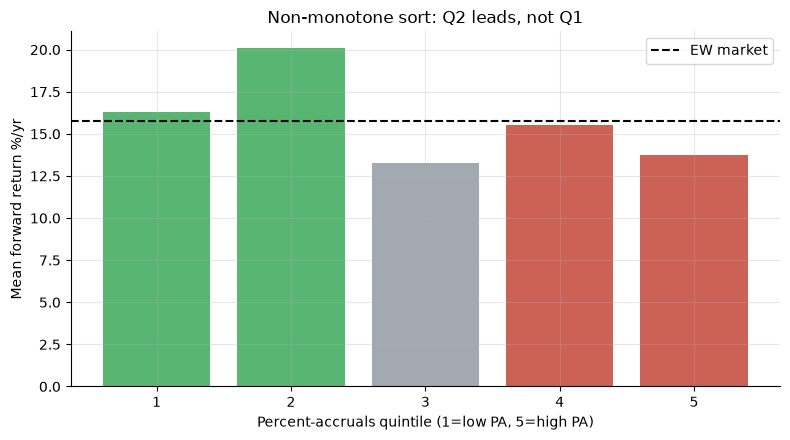

In [2]:
# Quintile means + HAC t-stats from the real tape
if HAVE_REAL:
    rows = []
    for q in ['q1','q2','q3','q4','q5','market']:
        s = st.summary(h[q])
        rows.append((q, s['mean']*100, s['sharpe'], s['tstat'], s['hit_rate']*100))
    qt = pd.DataFrame(rows, columns=['quintile','mean_%','sharpe','HAC_t','hit_%']).set_index('quintile')
    display(qt.round(2))
    fig, ax = plt.subplots(figsize=(8,4.5))
    means = [st.summary(h[f'q{i}'])['mean']*100 for i in range(1,6)]
    ax.bar(range(1,6), means, color=[GREEN,GREEN,GREY,RED,RED], alpha=.8)
    ax.axhline(st.summary(h['market'])['mean']*100, c='k', ls='--', label='EW market')
    ax.set_xlabel('Percent-accruals quintile (1=low PA, 5=high PA)')
    ax.set_ylabel('Mean forward return %/yr'); ax.set_title('Non-monotone sort: Q2 leads, not Q1'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('Quintile means (frozen): Q1=%.1f Q5=%.1f mkt=%.1f' % (R['q1_mean'],R['q5_mean'],R['mkt_mean']))

## 2 - The hedge and its HAC t-stat

Q1 - Q5 hedge: **+2.6%/yr gross**, HAC Newey-West *t* = **0.84**, hit rate 47%. Below the |t| >= 2 bar.

gross hedge mean=+2.57%/yr  Sharpe=+0.15  HAC t=+0.84  hit=47%  n=17


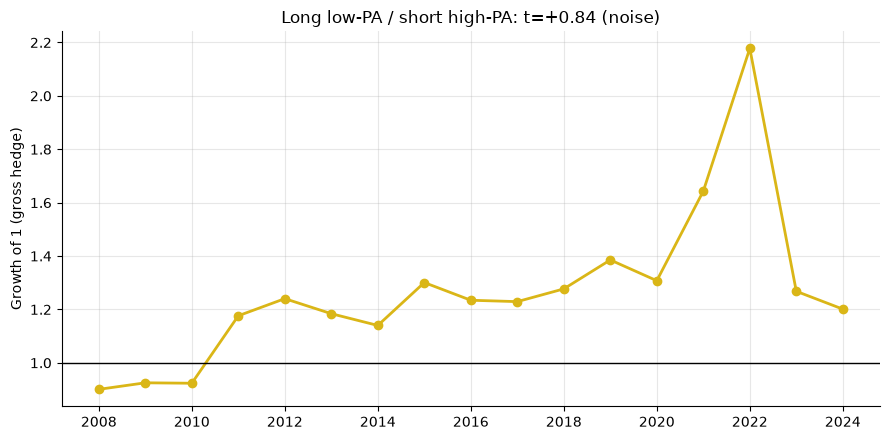

In [3]:
# The hedge series, HAC stat, and equity curve
if HAVE_REAL:
    hedge = h['hedge']
    s = st.summary(hedge)
    print(f"gross hedge mean={s['mean']*100:+.2f}%/yr  Sharpe={s['sharpe']:+.2f}  "
          f"HAC t={s['tstat']:+.2f}  hit={s['hit_rate']:.0%}  n={s['n']}")
    eq = (1+hedge).cumprod()
    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.plot([int(y) for y in eq.index], eq.values, 'o-', c=AMBER, lw=2)
    ax.axhline(1, c='k', lw=1)
    ax.set_ylabel('Growth of 1 (gross hedge)')
    ax.set_title(f'Long low-PA / short high-PA: t={s["tstat"]:+.2f} (noise)')
    plt.tight_layout(); plt.show()
else:
    print('frozen hedge t = %.2f' % R['hedge_t'])

## 3 - The label-shuffle placebo

Permute the percent-accruals labels *within each year* (1000 perms), breaking the signal->return link while preserving each year's return marginals. If the real *t* is not in the tail of the shuffled distribution, there is no signal.

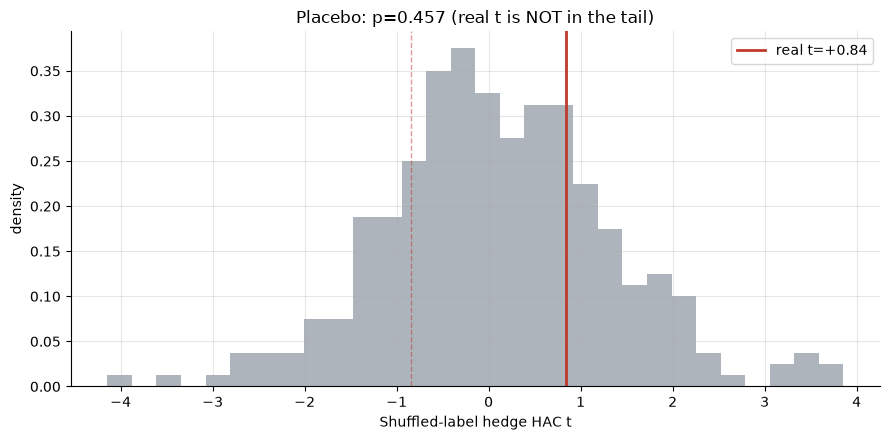

placebo p=0.457  (frozen full-run p=0.460)


In [4]:
# Label-shuffle placebo (reduced perms for a fast notebook cell)
if HAVE_REAL:
    p, null = st.placebo_hedge_t(sig, fwd, q=0.20, n_perm=300, min_names=15, seed=522)
    real_t = st.summary(h['hedge'])['tstat']
    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.hist(null, bins=30, color=GREY, alpha=.7, density=True)
    ax.axvline(real_t, c=RED, lw=2, label=f'real t={real_t:+.2f}')
    ax.axvline(-real_t, c=RED, lw=1, ls='--', alpha=.5)
    ax.set_xlabel('Shuffled-label hedge HAC t'); ax.set_ylabel('density')
    ax.set_title(f'Placebo: p={p:.3f} (real t is NOT in the tail)'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'placebo p={p:.3f}  (frozen full-run p={R["placebo_p"]:.3f})')
else:
    print('frozen placebo p = %.3f' % R['placebo_p'])

## 4 - Random-portfolio null and the synthetic positive control

Does the low-PA basket beat a random same-size draw? It beats only **54%** -- a coin flip. And the synthetic control proves the engine *would* detect a real effect (mean *t* = +9.9 with a planted -5%/yr premium over 20 seeds; null mean *t* = +0.02). Note the single-seed null *t* = +2.58 -- a lucky-seed artefact the 20-seed average correctly washes out.

In [5]:
# Synthetic control averaged over 20 seeds (faithful-engine + lucky-seed lesson)
null_ts = [st.synthetic_hedge_t(0.0, seed=s) for s in range(20)]
strong_ts = [st.synthetic_hedge_t(-0.05, seed=s) for s in range(20)]
print(f'null   premium: mean t over 20 seeds = {np.mean(null_ts):+.2f}  '
      f'(single seed 522 = {st.synthetic_hedge_t(0.0,522):+.2f}, a lucky-seed artefact)')
print(f'strong premium: mean t over 20 seeds = {np.mean(strong_ts):+.2f}  '
      f'(frac |t|>2 = {np.mean([abs(t)>2 for t in strong_ts]):.0%})')
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=300, seed=522)
    actual_lo = float((h['q1']-h['market']).mean())
    print(f'random null std={rand.std()*100:.1f}%  low-PA beats {(rand<actual_lo).mean():.0%} of draws')

null   premium: mean t over 20 seeds = +0.02  (single seed 522 = +2.58, a lucky-seed artefact)
strong premium: mean t over 20 seeds = +9.89  (frac |t|>2 = 100%)
random null std=7.9%  low-PA beats 54% of draws


## 5 - Costs and the Sloan head-to-head

Net of 62%/yr turnover (10 bps/leg x 2) plus 50 bps/yr borrow on the short leg: +1.9%/yr, *t* = 0.64. And the denominator race: Sloan's asset-scaled accrual reached *t* = +2.73 on a comparable survivor panel (Study 231); the earnings-scaled percent accrual lands +0.84.

GROSS +2.6%/yr t=+0.84  ->  NET +1.9%/yr t=+0.64  (turnover 62%/yr)


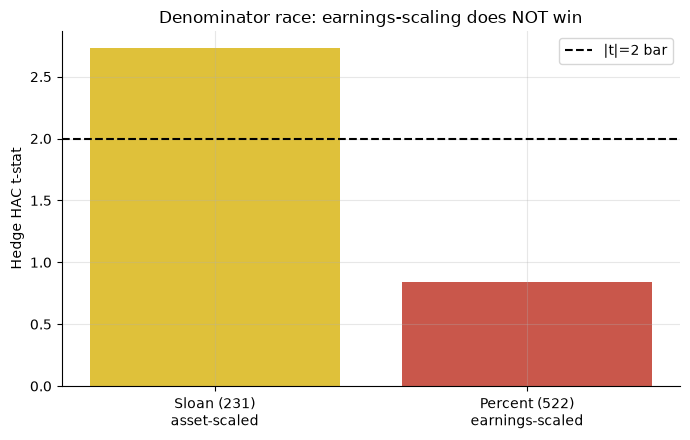

In [6]:
# Costs + Sloan head-to-head bar
if HAVE_REAL:
    turn = st.turnover_series(sig, fwd, q=0.20, min_names=15)
    net = st.apply_costs(h['hedge'], turn, one_way_bps=10.0, borrow_bps=50.0)
    g, n = st.summary(h['hedge']), st.summary(net)
    print(f"GROSS +{g['mean']*100:.1f}%/yr t={g['tstat']:+.2f}  ->  "
          f"NET +{n['mean']*100:.1f}%/yr t={n['tstat']:+.2f}  (turnover {turn.mean():.0%}/yr)")
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(['Sloan (231)\nasset-scaled','Percent (522)\nearnings-scaled'],
       [R['sloan_t'], R['hedge_t']], color=[AMBER, RED], alpha=.85)
ax.axhline(2.0, c='k', ls='--', label='|t|=2 bar'); ax.legend()
ax.set_ylabel('Hedge HAC t-stat'); ax.set_title('Denominator race: earnings-scaling does NOT win')
plt.tight_layout(); plt.show()

## 6 - Robustness summary

| Check | Result |
|---|---|
| Gross hedge HAC *t* | +0.84 (below 2) |
| Net hedge HAC *t* | +0.64 |
| Label-shuffle placebo *p* | 0.46 (seed-stable ~0.46) |
| Low-PA beats random draw | 54% |
| Sort monotone? | No (Q2 leads Q1) |
| Synthetic null mean *t* (20 seeds) | +0.02 |
| Synthetic strong mean *t* (20 seeds) | +9.9 |
| vs Sloan asset-scaled (Study 231) | +0.84 vs +2.73 |

Every robustness lens agrees: **no signal**, and the earnings-scaling is the *weaker* denominator here.

## 7 - Going further

- **Universe.** HLVW (2011) used value-weighted deciles on all US stocks 1989-2008 including small caps -- where both accrual flavours actually live.
- **Percent total accruals.** The broader balance-sheet accrual scaled by earnings is HLVW's second variant; worth a separate sleeve.
- **The benchmark.** [Study 231 -- Sloan-Accruals](../../231-sloan-accruals/) is the asset-scaled head-to-head; [Study 153 -- NOA](../../153-net-operating-assets/) the balance-sheet cousin.

*The honest read: on large-cap survivors, the percent-accruals denominator does not sharpen the Sloan sort -- and neither sort clears |t| >= 2 here.*